In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from torchvision import datasets , transforms
from torch.utils.data import random_split,DataLoader
import matplotlib.pyplot as plt
from torchmetrics import Accuracy
import seaborn as sns
from sklearn.metrics import confusion_matrix

#  1. Environment Setup & Importing Libraries

In this section, we set up our working environment by importing all necessary Python packages and frameworks required for deep learning, data manipulation, evaluation metrics, and visualization.

### Key Libraries Included:
* **Deep Learning Framework:** `torch`, `torch.nn`, and `torch.optim` for constructing neural network architectures, defining loss functions, and optimization algorithms.
* **Computer Vision & Data Processing:** `torchvision.datasets`, `transforms`, and PyTorch `DataLoader` for loading and preprocessing image datasets effectively.
* **Evaluation Metrics:** `torchmetrics.Accuracy` and `sklearn.metrics.confusion_matrix` for tracking model accuracy and analyzing classification results.
* **Data Visualization:** `matplotlib.pyplot` and `seaborn` for plotting loss curves, accuracy trends, and confusion matrices.

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    train_dataset,
    [50000, 10000]
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]


# 2. Data Loading and Preprocessing

In this step, we load the MNIST dataset using torchvision, apply necessary preprocessing transformations, and split the training set into training and validation subsets.

### Key Operations:
* **Image Transformation:** `transforms.ToTensor()` converts PIL images or NumPy arrays into PyTorch Tensors and scales pixel values from `[0, 255]` to `[0.0, 1.0]`.
* **Dataset Loading:** The MNIST dataset is downloaded and loaded for both training and testing.
* **Validation Split:** Using `random_split`, the original 60,000 training samples are split into:
  * **Training Set:** 50,000 samples for model training.
  * **Validation Set:** 10,000 samples for hyperparameter tuning and model evaluation during training.

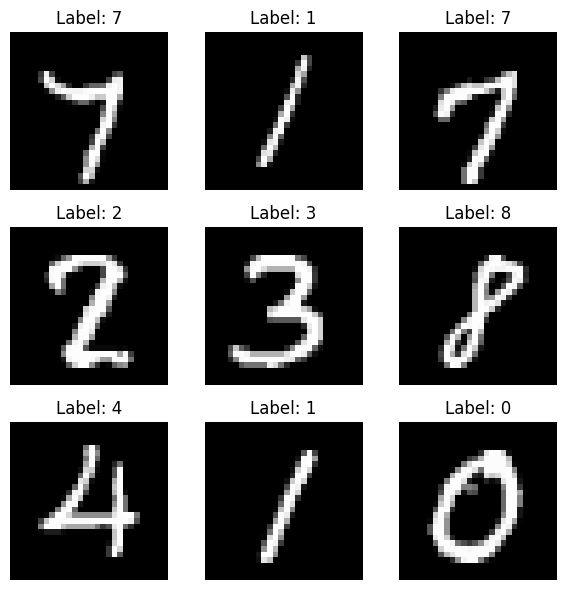

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Exploratory Data Analysis & Visualization

Visualizing sample images from the training dataset helps verify the correctness of image transformations and inspect the data structure before model training.

### Key Operations:
* **Grid Display:** Creates a 3x3 subplot grid using `matplotlib.pyplot` to display 9 random or sequential samples from `train_dataset`.
* **Dimension Squeezing:** `image.squeeze()` removes the single color channel dimension (converting shape from `[1, 28, 28]` to `[28, 28]`) for proper grayscale rendering.
* **Label Verification:** Displays the corresponding ground-truth class label above each image.

In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [5]:
image,label = next(iter(train_loader))

print(image.shape)
print(label.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


# 4. Data Iteration and Batching

Constructing PyTorch DataLoaders to wrap datasets into mini-batches for efficient memory management and optimization during training and evaluation.

### Key Operations:
* **Batch Configuration:** Data is batched into size `32` across all splits (`train`, `val`, `test`).
* **Data Shuffling:** `shuffle=True` is applied strictly to `train_loader` to prevent model bias across epochs, while set to `False` for evaluation loaders to maintain evaluation consistency.
* **Batch Shape Verification:** Fetching a single mini-batch using `next(iter(train_loader))` to verify tensor dimensions:
  * **Images Tensor Shape:** `[32, 1, 28, 28]` (Batch Size, Channels, Height, Width).
  * **Labels Tensor Shape:** `[32]` (Corresponding class targets for each image).

In [6]:
class MNISTNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        nn.init.kaiming_normal_(self.block1[0].weight, a=0, mode='fan_in', nonlinearity='relu')
        if self.block1[0].bias is not None:
            nn.init.constant_(self.block1[0].bias, 0.0)

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        nn.init.kaiming_normal_(self.block2[0].weight, a=0, mode='fan_in', nonlinearity='relu')
        if self.block2[0].bias is not None:
            nn.init.constant_(self.block2[0].bias, 0.0)

        # Flatten & Block 3 (Classifier)
        self.flatten = nn.Flatten()

        # 64 channels * 7 height * 7 width = 3136
        self.block3 = nn.Sequential(
            nn.Linear(in_features=64 * 7 * 7, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        x = self.block3(x)
        return x

# 5. Model Architecture Definition

Building a Convolutional Neural Network (CNN) architecture (`MNISTNN`) using PyTorch `nn.Module` to extract spatial features and classify handwritten digits.

### Architecture Breakdown:
* **Block 1 (Feature Extractor Part 1):**
  * `Conv2d`: 1 input channel to 32 output channels with $3 \times 3$ kernel and padding 1 to retain spatial dimensions ($28 \times 28$).
  * `ReLU`: Non-linear activation function.
  * `MaxPool2d`: Downsamples feature maps by half to $14 \times 14$ using a $2 \times 2$ window with stride 2.
* **Block 2 (Feature Extractor Part 2):**
  * `Conv2d`: 32 input channels to 64 output channels with $3 \times 3$ kernel and padding 1.
  * `ReLU`: Activation function.
  * `MaxPool2d`: Downsamples feature maps by half to $7 \times 7$.
* **Weight Initialization:** Applies Kaiming (He) normal initialization (`kaiming_normal_`) optimized for ReLU activation layers, and zeroes bias parameters (`constant_`).
* **Flatten Layer:** `nn.Flatten()` reshapes the 2D spatial feature tensor into a 1D vector ($64 \times 7 \times 7 = 3136$) for dense classification layers.

In [7]:
def train_eval_model(model, optimizer, criterion, train_loader, val_loader, epochs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    history = {
        "loss" : [],
        'accuracy' : [],
        "val_accuracy" : [],
        "val_loss" : []
    }

    model = model.to(device)


    train_accuracy = Accuracy(task='multiclass', num_classes=10).to(device)
    val_accuracy = Accuracy(task='multiclass', num_classes=10).to(device)

    for epoch in range(epochs):
        # ---------------- Training Phase ----------------
        model.train()
        total_train_loss = 0.0
        train_accuracy.reset()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_accuracy(output, labels)

        # ---------------- Validation Phase ----------------
        model.eval()
        total_val_loss = 0.0
        val_accuracy.reset()

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                output = model(images)
                loss = criterion(output, labels)

                total_val_loss += loss.item()
                val_accuracy(output, labels)

        # ---------------- Metrics Computation ----------------
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        final_accuracy_train = train_accuracy.compute().item() * 100
        final_accuracy_val = val_accuracy.compute().item() * 100
        history['loss'].append(avg_train_loss)
        history['accuracy'].append(final_accuracy_train)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(final_accuracy_val)

        print(f"Epoch: {epoch+1:02d} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Train Acc: {final_accuracy_train:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {final_accuracy_val:.2f}%")
    return history

# 6. Training and Validation Pipeline Setup

Defining the primary pipeline function `train_eval_model` to manage model training, validation evaluation, metric computations, and performance tracking across training epochs.

### Key Operations:
* **Device Allocation:** Automatically assigns computational workloads to GPU (`cuda`) if available, or defaults to CPU.
* **History Tracking:** Initializes a tracking dictionary `history` to store loss and accuracy trends (`loss`, `accuracy`, `val_loss`, `val_accuracy`) per epoch.
* **Metric Initialization:** Configures TorchMetrics `Accuracy` objects for multi-class classification ($10$ classes) and binds them to the specified compute device.
* **Training Sub-Loop:** 
  * Sets the model to training mode (`model.train()`).
  * Resets metric state at the start of each epoch (`train_accuracy.reset()`).
  * Transfers batch inputs (`images`, `labels`) to the compute device.
  * Clears gradients (`optimizer.zero_grad()`), computes forward pass predictions, calculates loss, and backpropagates gradients (`loss.backward()`).

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTNN().to(device)
optimizer = optim.AdamW(model.parameters() , lr=0.003 , weight_decay=0.01)
loss = nn.CrossEntropyLoss()

# 7. Model Initialization and Training Execution

Instantiating the neural network model, setting up optimization hyper-parameters, loss function, and executing the full training pipeline across specified epochs.

### Key Operations:
* **Model Instantiation:** Creates an instance of `MNISTNN` and moves its weights to the target target device (`cuda` or `cpu`).
* **Optimizer Configuration:** Uses `optim.AdamW` with learning rate `lr=0.003` and weight decay `weight_decay=0.01` to penalize large weights and prevent overfitting.
* **Loss Function:** Employs `nn.CrossEntropyLoss()` for multi-class classification, combining `LogSoftmax` and `NLLLoss` into a single class.
* **Training Run:** Executes `train_eval_model` for 10 epochs, recording loss and accuracy progression for both training and validation sets.

In [9]:
train_val = train_eval_model(
    model=model,
    optimizer=optimizer,
    criterion=loss,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10
)

Epoch: 01 | Train Loss: 0.1135 | Train Acc: 96.41% | Val Loss: 0.0586 | Val Acc: 98.32%
Epoch: 02 | Train Loss: 0.0435 | Train Acc: 98.67% | Val Loss: 0.0592 | Val Acc: 98.37%
Epoch: 03 | Train Loss: 0.0306 | Train Acc: 99.02% | Val Loss: 0.0566 | Val Acc: 98.53%
Epoch: 04 | Train Loss: 0.0248 | Train Acc: 99.23% | Val Loss: 0.0573 | Val Acc: 98.42%
Epoch: 05 | Train Loss: 0.0200 | Train Acc: 99.35% | Val Loss: 0.0473 | Val Acc: 98.79%
Epoch: 06 | Train Loss: 0.0195 | Train Acc: 99.39% | Val Loss: 0.0619 | Val Acc: 98.55%
Epoch: 07 | Train Loss: 0.0163 | Train Acc: 99.44% | Val Loss: 0.0667 | Val Acc: 98.52%
Epoch: 08 | Train Loss: 0.0152 | Train Acc: 99.52% | Val Loss: 0.0600 | Val Acc: 98.44%
Epoch: 09 | Train Loss: 0.0108 | Train Acc: 99.68% | Val Loss: 0.0660 | Val Acc: 98.43%
Epoch: 10 | Train Loss: 0.0137 | Train Acc: 99.59% | Val Loss: 0.0766 | Val Acc: 98.33%


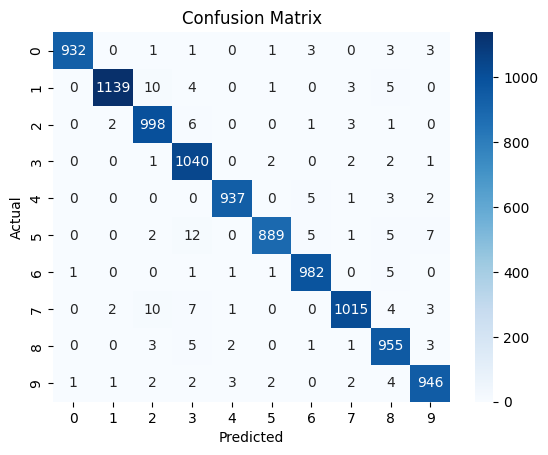

In [10]:
def confusionm(model,val_loader):
    with torch.inference_mode():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.eval()
        all_labels = []
        all_preds = []
        for features,labels in val_loader:
            features,labels = features.to(device) , labels.to(device)
            output = model(features).to(device)
            pred = torch.argmax(output,dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())

        cm = confusion_matrix(all_labels,all_preds)
        return cm

cm = confusionm(model=model,val_loader=val_loader)
class_names = [str(i) for i in range(10)]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. Model Evaluation & Confusion Matrix Visualization

Generating and plotting a confusion matrix to evaluate class-wise model predictions and identify specific misclassification patterns across validation samples.

### Key Operations:
* **Prediction Aggregation:** Iterates over `val_loader` in inference mode (`torch.inference_mode()`) to gather ground-truth targets (`all_labels`) and model predicted class indices using `torch.argmax(output, dim=1)`.
* **Confusion Matrix Computation:** Uses Scikit-Learn `confusion_matrix` to generate a $10 \times 10$ matrix comparing actual vs. predicted digit labels.
* **Heatmap Plotting:** Renders the matrix using `seaborn.heatmap` with integer annotations (`fmt="d"`), class label ticks (`0-9`), and a blue color palette (`cmap='Blues'`) for visual inspection.

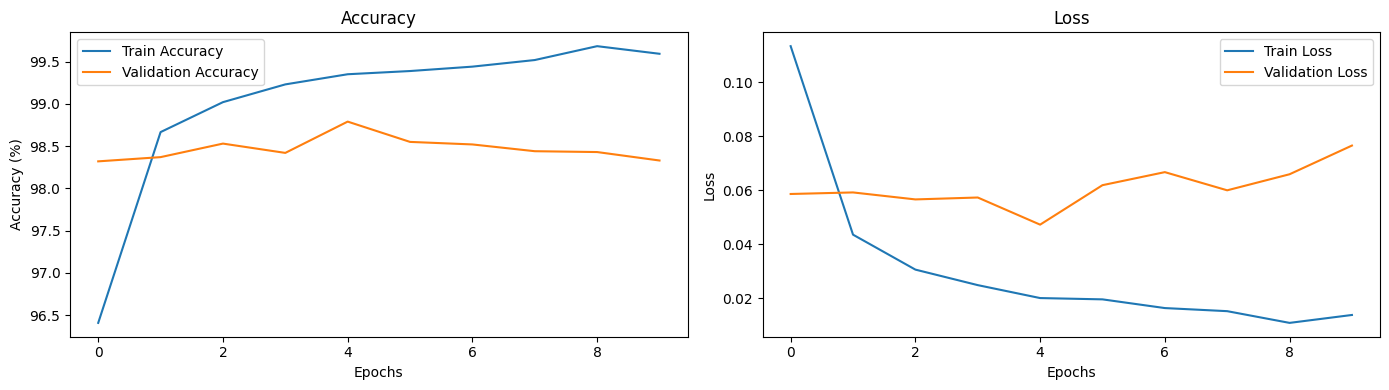

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_val["accuracy"], label="Train Accuracy")
axes[0].plot(train_val["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

axes[1].plot(train_val["loss"], label="Train Loss")
axes[1].plot(train_val["val_loss"], label="Validation Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# 9. Loss and Accuracy Learning Curves

Plotting training and validation performance history across epochs to evaluate learning convergence, detect overfitting, and analyze model stability.

### Key Operations:
* **Accuracy Subplot (`axes[0]`):** Visualizes training vs. validation accuracy percentages over time to monitor performance improvements and convergence.
* **Loss Subplot (`axes[1]`):** Displays training vs. validation cross-entropy loss trends to assess generalization ability and check for divergence or overfitting.
* **Layout Formatting:** Applies explicit axis labels (`Epochs`, `Accuracy (%)`, `Loss`), titles, legends, and `plt.tight_layout()` for clear display.

In [12]:
def test_model(model,test_loader,criterion):
  model.eval()
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  with torch.inference_mode():
    total_loss = 0.0
    accuracy = Accuracy(task='multiclass' , num_classes=10).to(device)
    for images,labels in test_loader:
      images,labels = images.to(device),labels.to(device)
      output = model(images).to(device)
      loss = criterion(output,labels)
      total_loss += loss.item()
      accuracy(output,labels)

  avg_test_loss = total_loss / len(test_loader)
  final_test_acc = accuracy.compute().item() * 100
    
  print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {final_test_acc:.2f}")

test_model(model,test_loader,loss)

Test Loss: 0.0600 | Test Accuracy: 98.41


# 10. Model Evaluation on Unseen Test Dataset

Evaluating the trained model on the unseen test set (`test_loader`) to measure generalization performance and obtain final test metrics.

### Key Operations:
* **Evaluation Mode:** Enforces `model.eval()` and disables gradient computation with `torch.inference_mode()` to optimize memory usage and execution speed.
* **Metric Calculation:** Iterates through test mini-batches to calculate total test loss and compute overall accuracy across all 10 classes using TorchMetrics `Accuracy`.
* **Final Results Output:** Computes average test loss (`avg_test_loss`) and total accuracy percentage (`final_test_acc`), displaying final test performance.

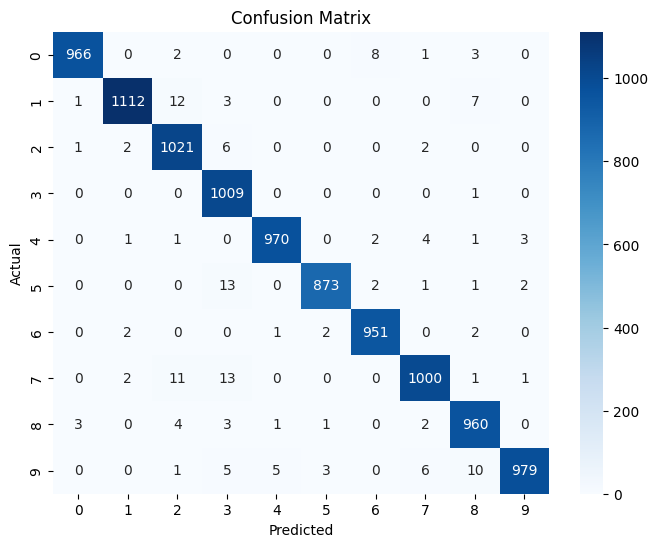

In [13]:
model.eval()
all_preds, all_labels = [], []

with torch.inference_mode():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 11. Test Set Confusion Matrix Analysis

Evaluating final model performance on the test set using a confusion matrix to visualize actual vs. predicted classifications across all test samples.

### Key Operations:
* **Prediction Generation:** Iterates through `test_loader` using `torch.inference_mode()` to extract predictions (`preds`) using `torch.argmax(outputs, dim=1)` and accumulate true target labels (`all_labels`).
* **Matrix Calculation:** Generates the confusion matrix via Scikit-Learn `confusion_matrix` on test dataset predictions.
* **Visualization:** Plots the resulting matrix using `seaborn.heatmap` with explicit class labels, axis titles (`Predicted` vs. `Actual`), and integer counts to analyze misclassification patterns.

In [14]:
torch.save(model.state_dict(), 'mnist_model.pth')

# 12. Saving Model Weights

Saving the trained model weights (`state_dict`) for future inference, deployment, or further fine-tuning.

### Key Operations:
* **State Dictionary Serialization:** `model.state_dict()` extracts all learnable parameters (weights and biases) of the trained network.
* **Model Persistence:** Uses `torch.save()` to write the parameters to disk as `'mnist_model.pth'`, providing a lightweight and standard format for PyTorch model deployment.